# Logistic Regression


### Model Suitability

Logistic Regression was selected for this classification task due to its strong alignment with the project's objectives and data characteristics. As a binary classifier, it is inherently suitable for predicting our categorical target variable. The model offers high interpretability, allowing for clear insight into the relationship between input features and the predicted outcome. Furthermore, its ability to output class probabilities, rather than just final classifications, provides a more nuanced understanding of prediction confidence. For a dataset of this size, Logistic Regression provides an
efficient, robust, and well-understood baseline model.

In [1]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings("ignore")

# Load the dataset
df = pd.read_csv("../../results/outputs/final_preprocessed_telco_data_new.csv")
print(f"Dataset shape: {df.shape}")

# Split into features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train-Test Split (Stratified for balanced classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Dataset shape: (7043, 11)


#### VARIETY A: Baseline Logistic Regression (no tuning)


In [2]:
# Create and train baseline model
baseline_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
baseline_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [3]:
# Evaluation metrics for Baseline Model
y_pred_a = baseline_model.predict(X_test)
y_prob_a = baseline_model.predict_proba(X_test)[:, 1]

print("\n=== VARIETY A: Baseline Logistic Regression ===")
print("Accuracy :", accuracy_score(y_test, y_pred_a))
print("F1 Score :", f1_score(y_test, y_pred_a))
print("Precision:", precision_score(y_test, y_pred_a))
print("Recall   :", recall_score(y_test, y_pred_a))
print("AUC      :", roc_auc_score(y_test, y_prob_a))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_a))
print("\nClassification Report:\n", classification_report(y_test, y_pred_a, digits=4))


=== VARIETY A: Baseline Logistic Regression ===
Accuracy : 0.7842441447835344
F1 Score : 0.5449101796407185
Precision: 0.6190476190476191
Recall   : 0.48663101604278075
AUC      : 0.8352876592007026

Confusion Matrix:
 [[923 112]
 [192 182]]

Classification Report:
               precision    recall  f1-score   support

           0     0.8278    0.8918    0.8586      1035
           1     0.6190    0.4866    0.5449       374

    accuracy                         0.7842      1409
   macro avg     0.7234    0.6892    0.7018      1409
weighted avg     0.7724    0.7842    0.7753      1409



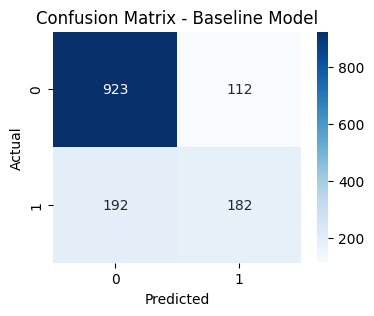

In [4]:
# Plot Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_a), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Baseline Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### VARIETY B: Tuned Model using GridSearchCV (penalty, C, class_weight)


In [5]:
# Define the model and parameter grid
model_b = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

param_grid_b = {
    "penalty": ["l1", "l2"],
    "C": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    "class_weight": [None, "balanced"]
}

# Perform GridSearchCV with F1 scoring
grid_b = GridSearchCV(model_b, param_grid_b, scoring="f1", cv=cv, n_jobs=-1, verbose=1)
grid_b.fit(X_train, y_train)

print("\nBest Parameters (Variety B):", grid_b.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters (Variety B): {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2'}


In [6]:
# Evaluate the best model from GridSearchCV
y_pred_b = grid_b.predict(X_test)
y_prob_b = grid_b.predict_proba(X_test)[:, 1]

print("\n=== VARIETY B: Tuned Logistic Regression (liblinear) ===")
print("Accuracy :", accuracy_score(y_test, y_pred_b))
print("F1 Score :", f1_score(y_test, y_pred_b))
print("Precision:", precision_score(y_test, y_pred_b))
print("Recall   :", recall_score(y_test, y_pred_b))
print("AUC      :", roc_auc_score(y_test, y_prob_b))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_b))
print("\nClassification Report:\n", classification_report(y_test, y_pred_b, digits=4))


=== VARIETY B: Tuned Logistic Regression (liblinear) ===
Accuracy : 0.7444996451383961
F1 Score : 0.6218487394957983
Precision: 0.5121107266435986
Recall   : 0.7914438502673797
AUC      : 0.8349130693120462

Confusion Matrix:
 [[753 282]
 [ 78 296]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9061    0.7275    0.8071      1035
           1     0.5121    0.7914    0.6218       374

    accuracy                         0.7445      1409
   macro avg     0.7091    0.7595    0.7145      1409
weighted avg     0.8015    0.7445    0.7579      1409



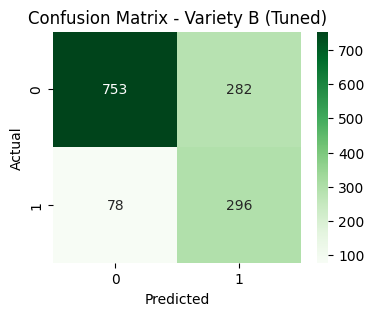

In [7]:
# Plot Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_b), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Variety B (Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### VARIETY C: Tuned Model using 'saga' solver with ElasticNet


In [8]:
# Define the model for saga solver
model_c = LogisticRegression(random_state=42, solver='saga', max_iter=5000)

# Define parameter grid for saga solver
param_grid_c = [
    {
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 0.5, 1.0, 5.0],
        "class_weight": [None, "balanced"]
    },
    {
        "penalty": ["elasticnet"],
        "C": [0.01, 0.1, 0.5, 1.0],
        "class_weight": [None, "balanced"],
        "l1_ratio": [0.2, 0.5, 0.8]
    },
]

# Perform GridSearchCV with F1 scoring
grid_c = GridSearchCV(model_c, param_grid_c, scoring="f1", cv=cv, n_jobs=-1, verbose=1)
grid_c.fit(X_train, y_train)

print("\nBest Parameters (Variety C):", grid_c.best_params_)

Fitting 5 folds for each of 44 candidates, totalling 220 fits

Best Parameters (Variety C): {'C': 0.1, 'class_weight': 'balanced', 'l1_ratio': 0.2, 'penalty': 'elasticnet'}


In [9]:
# Evaluate the best model
y_pred_c = grid_c.predict(X_test)
y_prob_c = grid_c.predict_proba(X_test)[:, 1]

print("\n=== VARIETY C: Tuned Logistic Regression (saga + elasticnet) ===")
print("Accuracy :", accuracy_score(y_test, y_pred_c))
print("F1 Score :", f1_score(y_test, y_pred_c))
print("Precision:", precision_score(y_test, y_pred_c))
print("Recall   :", recall_score(y_test, y_pred_c))
print("AUC      :", roc_auc_score(y_test, y_prob_c))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_c))
print("\nClassification Report:\n", classification_report(y_test, y_pred_c, digits=4))


=== VARIETY C: Tuned Logistic Regression (saga + elasticnet) ===
Accuracy : 0.7437899219304471
F1 Score : 0.621196222455404
Precision: 0.5112262521588946
Recall   : 0.7914438502673797
AUC      : 0.8351507401379524

Confusion Matrix:
 [[752 283]
 [ 78 296]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9060    0.7266    0.8064      1035
           1     0.5112    0.7914    0.6212       374

    accuracy                         0.7438      1409
   macro avg     0.7086    0.7590    0.7138      1409
weighted avg     0.8012    0.7438    0.7573      1409



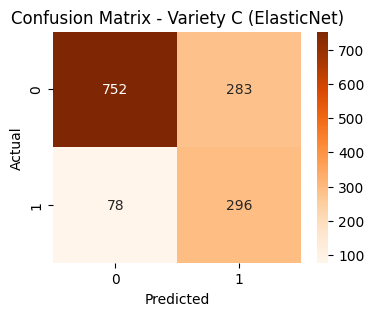

In [10]:
# Plot Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_c), annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Variety C (ElasticNet)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Comparison of all Varieties


In [11]:
# Collect metrics from each model for comparison
comparison = pd.DataFrame({
    "Model": ["Baseline", "Variety B (liblinear tuned)", "Variety C (saga tuned)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_a),
        accuracy_score(y_test, y_pred_b),
        accuracy_score(y_test, y_pred_c)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_a),
        f1_score(y_test, y_pred_b),
        f1_score(y_test, y_pred_c)
    ],
    "Precision": [
        precision_score(y_test, y_pred_a),
        precision_score(y_test, y_pred_b),
        precision_score(y_test, y_pred_c)
    ],
    "Recall": [
        recall_score(y_test, y_pred_a),
        recall_score(y_test, y_pred_b),
        recall_score(y_test, y_pred_c)
    ],
    "AUC": [
        roc_auc_score(y_test, y_prob_a),
        roc_auc_score(y_test, y_prob_b),
        roc_auc_score(y_test, y_prob_c)
    ]
})

print("\n=== Model Comparison Table ===")
print(comparison)


=== Model Comparison Table ===
                         Model  Accuracy  F1 Score  Precision    Recall  \
0                     Baseline  0.784244  0.544910   0.619048  0.486631   
1  Variety B (liblinear tuned)  0.744500  0.621849   0.512111  0.791444   
2       Variety C (saga tuned)  0.743790  0.621196   0.511226  0.791444   

        AUC  
0  0.835288  
1  0.834913  
2  0.835151  




* Baseline has the highest accuracy (0.784) but very low F1 (0.545) and recall (0.487).
* Variety B & C have lower accuracy (~ 0.744) but much higher F1 (~ 0.622) and recall (~0.791).
* AUC is almost the same for all (~0.835).

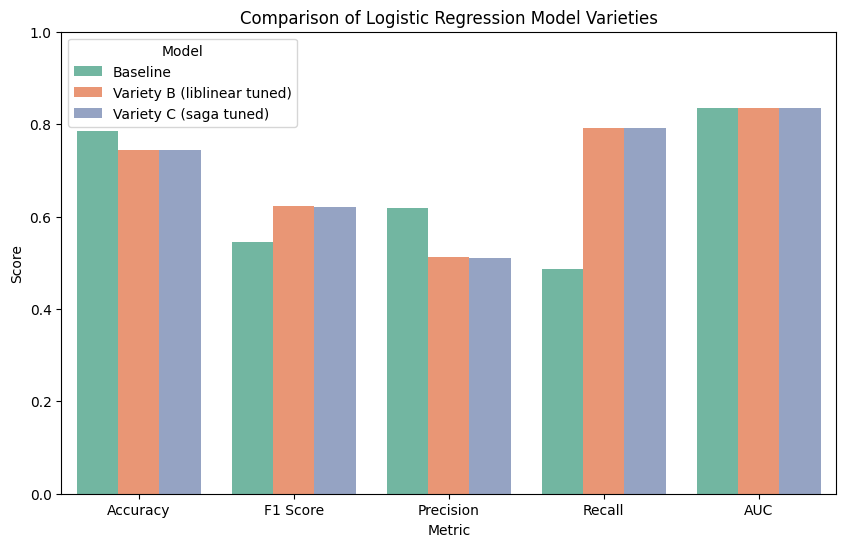

In [12]:
# Plot Comparison (Visual summary of all varieties)
plt.figure(figsize=(10,6))
metrics = ["Accuracy", "F1 Score", "Precision", "Recall", "AUC"]
comparison_melted = comparison.melt(id_vars="Model", value_vars=metrics,
                                    var_name="Metric", value_name="Score")

sns.barplot(data=comparison_melted, x="Metric", y="Score", hue="Model", palette="Set2")
plt.title("Comparison of Logistic Regression Model Varieties")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.show()

### Interpretation:

Baseline is more conservative, predicting the majority class, which gives high accuracy but fails on minority class (low recall & F1).

Tuned varieties (B & C) trade a little accuracy for much better balance between precision and recall, which is usually better for imbalanced datasets.

### Conclusion:

Although the baseline Logistic Regression model achieved the highest accuracy (0.784), it struggled with minority class prediction, as seen from its low recall and F1-score. After hyperparameter tuning using the liblinear and saga solvers, the tuned models demonstrated a better balance between precision and recall, making them more suitable for this dataset. Both tuned versions performed similarly, suggesting that Logistic Regression performs consistently across solver variations when class weighting and regularization are optimized.

### Limitations:

Logistic Regression assumes a linear relationship between input features and the target variable, which may limit performance if the data contains non-linear patterns. Additionally, its performance can be affected by class imbalance, even with class weighting adjustments.

### Observations:

Parameter tuning significantly improved model balance, emphasizing the importance of hyperparameter optimization. Metrics such as F1-score and recall provided a more realistic evaluation than accuracy alone, especially in this imbalanced dataset.

### Improvements

Further improvement could be achieved by trying non-linear models such as Random Forest or XGBoost, performing feature selection, and exploring resampling techniques (like SMOTE) to address imbalance.